# Model Evaluation Insights

Compare two STT runs using stored evaluation metrics and run metadata.

This notebook is designed to answer:
- Which model performs better overall?
- Which metrics improved/regressed?
- Are gains consistent or sample-specific?
- What parameter differences likely explain results?

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make project root importable when notebook runs from analysis/
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "analysis" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from analysis.eval_insights import (  # noqa: E402
    build_metric_summary,
    fetch_eval_rows,
    fetch_run_meta,
    recommend_winner_table,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

In [2]:
# Parameters
CANDIDATE_RUN_ID = os.getenv("CANDIDATE_RUN_ID", "9d126f1b-3c07-4f5c-a73d-fe812044c8c3")
BASELINE_RUN_ID = os.getenv("BASELINE_RUN_ID", "22282662-99a4-4901-af84-4374763e9610")
SAMPLE_ID = os.getenv("SAMPLE_ID", "D0420-S1-T01") or None

if not CANDIDATE_RUN_ID or not BASELINE_RUN_ID:
    raise ValueError("Set CANDIDATE_RUN_ID and BASELINE_RUN_ID in this cell (or as env vars).")

print("candidate:", CANDIDATE_RUN_ID)
print("baseline:", BASELINE_RUN_ID)
print("sample_id:", SAMPLE_ID)

candidate: e7fc04ce-2cb2-427a-afa2-e456438abf8f
baseline: 50a52f67-abce-47b6-939e-271013b3a4e0
sample_id: D0420-S1-T01


In [3]:
eval_df = fetch_eval_rows(
    candidate_run_id=CANDIDATE_RUN_ID,
    baseline_run_id=BASELINE_RUN_ID,
    sample_id=SAMPLE_ID,
)

meta_df = fetch_run_meta(CANDIDATE_RUN_ID, BASELINE_RUN_ID)
summary_df = build_metric_summary(eval_df, CANDIDATE_RUN_ID, BASELINE_RUN_ID)
winner_df = recommend_winner_table(summary_df, CANDIDATE_RUN_ID, BASELINE_RUN_ID)

print(f"rows loaded: {len(eval_df)}")
print(f"metrics found: {eval_df['metric_name'].nunique() if not eval_df.empty else 0}")

rows loaded: 6
metrics found: 6


## Run Metadata

Inspect model names, providers, run timestamps, and parameters before interpreting metrics.

In [4]:
display(meta_df)

if not meta_df.empty:
    for _, row in meta_df.iterrows():
        print("\n---")
        print("run_id:", row.get("run_id"))
        print("provider/model:", f"{row.get('provider')} / {row.get('model_name')}")
        print("run_scope:", row.get("run_scope"))
        print("run_timestamp:", row.get("run_timestamp"))
        print("run_parameters:")
        print(row.get("run_parameters"))

,run_id,provider,model_name,run_scope,run_timestamp,run_parameters
0,50a52f67-abce-47b6-939e-271013b3a4e0,mlx-whisper,mlx-community/whisper-large-v3-turbo,sample,2026-04-02 18:28:35.955809+00:00,"{'limit': 43, 'profile': 'default', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidate..."
1,e7fc04ce-2cb2-427a-afa2-e456438abf8f,mlx-whisper,mlx-community/whisper-large-v3-mlx,sample,2026-04-02 19:03:55.561544+00:00,"{'limit': 43, 'profile': 'quality', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidate..."



---
run_id: 50a52f67-abce-47b6-939e-271013b3a4e0
provider/model: mlx-whisper / mlx-community/whisper-large-v3-turbo
run_scope: sample
run_timestamp: 2026-04-02 18:28:35.955809+00:00
run_parameters:
{'limit': 43, 'profile': 'default', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidates_with_audio': 43}

---
run_id: e7fc04ce-2cb2-427a-afa2-e456438abf8f
provider/model: mlx-whisper / mlx-community/whisper-large-v3-mlx
run_scope: sample
run_timestamp: 2026-04-02 19:03:55.561544+00:00
run_parameters:
{'limit': 43, 'profile': 'quality', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidates_with_audio': 43}


## Aggregate Metric Comparison

Per metric, compare candidate vs baseline means and show directional winner.

In [5]:
display(summary_df)
display(winner_df)

candidate_wins = int((winner_df["winner"] == "candidate").sum()) if not winner_df.empty else 0
baseline_wins = int((winner_df["winner"] == "baseline").sum()) if not winner_df.empty else 0
print(f"candidate wins: {candidate_wins}")
print(f"baseline wins: {baseline_wins}")

,metric_name,run_id,samples,mean,median,std
7,cer,50a52f67-abce-47b6-939e-271013b3a4e0,1,0.207112,0.207112,NaN
0,cer,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,0.244467,0.244467,NaN
1,cp_wer,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,0.122457,0.122457,NaN
2,llm_judge_compare,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,3.000000,3.000000,NaN
3,mer,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,0.126259,0.126259,NaN
6,wer,50a52f67-abce-47b6-939e-271013b3a4e0,1,0.189990,0.189990,NaN
4,wer,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,0.239381,0.239381,NaN
5,wil,e7fc04ce-2cb2-427a-afa2-e456438abf8f,1,0.252518,0.252518,NaN


,metric_name,candidate_mean,baseline_mean,direction,winner,relative_delta_pct
0,cer,0.244467,0.207112,lower_is_better,baseline,-18.035944
1,wer,0.239381,0.189990,lower_is_better,baseline,-25.996534
2,llm_judge_compare,3.000000,0.000000,higher_is_better,candidate,30.000000


candidate wins: 1
baseline wins: 2


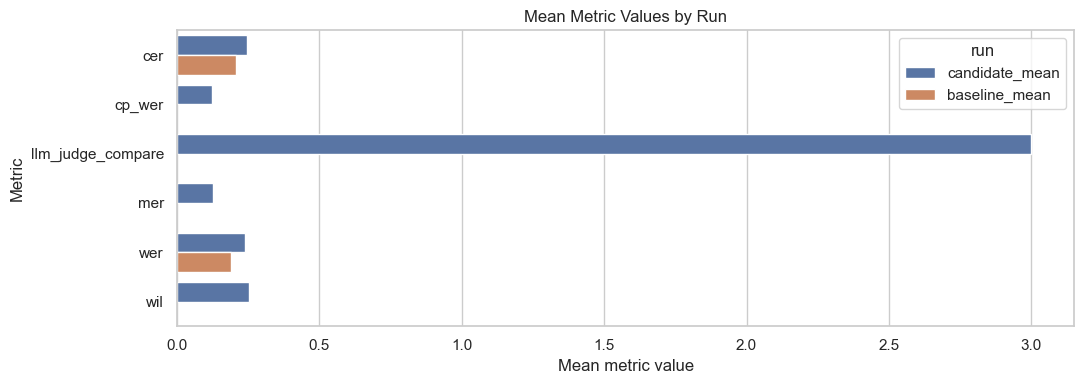

In [6]:
if not summary_df.empty:
    pivot = summary_df.pivot(index="metric_name", columns="run_id", values="mean").reset_index()
    pivot = pivot.rename(columns={
        CANDIDATE_RUN_ID: "candidate_mean",
        BASELINE_RUN_ID: "baseline_mean",
    })

    fig, ax = plt.subplots(figsize=(11, max(4, len(pivot) * 0.45)))
    plot_df = pivot.melt(id_vars="metric_name", value_vars=["candidate_mean", "baseline_mean"], var_name="run", value_name="mean")
    sns.barplot(data=plot_df, y="metric_name", x="mean", hue="run", ax=ax)
    ax.set_title("Mean Metric Values by Run")
    ax.set_xlabel("Mean metric value")
    ax.set_ylabel("Metric")
    plt.tight_layout()
    plt.show()

## Distribution and Stability

Visualize metric distributions to detect whether gains are broad or driven by outliers.

In [7]:
if not eval_df.empty:
    dist_df = eval_df.copy()
    dist_df["run_id"] = dist_df["details_run_id"].fillna("")
    dist_df = dist_df[dist_df["run_id"].isin([CANDIDATE_RUN_ID, BASELINE_RUN_ID])]

    metric_list = sorted(dist_df["metric_name"].dropna().unique())
    for metric in metric_list:
        sub = dist_df[dist_df["metric_name"] == metric]
        if sub.empty or sub["run_id"].nunique() < 2:
            continue
        plt.figure(figsize=(10, 4))
        sns.kdeplot(data=sub, x="metric_value", hue="run_id", fill=True, common_norm=False, alpha=0.25)
        plt.title(f"Distribution: {metric}")
        plt.xlabel("Metric value")
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()

## Per-Sample Delta View

For metrics available in both runs, show sample-level deltas (candidate - baseline).

In [8]:
if not eval_df.empty:
    work = eval_df.copy()
    work["run_id"] = work["details_run_id"].fillna("")
    work = work[work["run_id"].isin([CANDIDATE_RUN_ID, BASELINE_RUN_ID])]

    by_run = work.pivot_table(
        index=["sample_id", "metric_name"],
        columns="run_id",
        values="metric_value",
        aggfunc="mean",
    ).reset_index()

    if CANDIDATE_RUN_ID in by_run.columns and BASELINE_RUN_ID in by_run.columns:
        by_run["delta_candidate_minus_baseline"] = by_run[CANDIDATE_RUN_ID] - by_run[BASELINE_RUN_ID]
        display(by_run.sort_values("delta_candidate_minus_baseline", ascending=False).head(20))

        for metric in sorted(by_run["metric_name"].unique()):
            sub = by_run[by_run["metric_name"] == metric].copy()
            if sub.empty:
                continue
            plt.figure(figsize=(10, 4))
            sns.histplot(sub["delta_candidate_minus_baseline"], bins=30, kde=True)
            plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
            plt.title(f"Sample Delta Histogram: {metric} (candidate - baseline)")
            plt.xlabel("Delta")
            plt.tight_layout()
            plt.show()

## Recommendation Draft

This section turns metrics + metadata into a practical recommendation template.

In [9]:
def recommendation_text(winners: pd.DataFrame, meta: pd.DataFrame) -> str:
    if winners.empty:
        return "Not enough comparable metrics to recommend a winner."

    c_wins = int((winners["winner"] == "candidate").sum())
    b_wins = int((winners["winner"] == "baseline").sum())

    if c_wins > b_wins:
        winner = "candidate"
    elif b_wins > c_wins:
        winner = "baseline"
    else:
        winner = "tie"

    lines = []
    lines.append(f"Metric wins -> candidate: {c_wins}, baseline: {b_wins}")
    if winner == "tie":
        lines.append("Overall: tie. Choose based on operational constraints (latency/cost/risk).")
    else:
        lines.append(f"Overall recommendation: {winner} run.")

    lines.append("Top metric deltas (%):")
    top = winners.sort_values("relative_delta_pct", ascending=False).head(5)
    for _, r in top.iterrows():
        lines.append(
            f"- {r['metric_name']}: {r['relative_delta_pct']:+.2f}% ({r['winner']}, {r['direction']})"
        )

    if not meta.empty:
        lines.append("Run metadata:")
        for _, m in meta.iterrows():
            lines.append(
                f"- {m['run_id']}: {m.get('provider')} / {m.get('model_name')} | params={m.get('run_parameters')}"
            )

    return "\n".join(lines)

print(recommendation_text(winner_df, meta_df))

Metric wins -> candidate: 1, baseline: 2
Overall recommendation: baseline run.
Top metric deltas (%):
- llm_judge_compare: +30.00% (candidate, higher_is_better)
- cer: -18.04% (baseline, lower_is_better)
- wer: -26.00% (baseline, lower_is_better)
Run metadata:
- 50a52f67-abce-47b6-939e-271013b3a4e0: mlx-whisper / mlx-community/whisper-large-v3-turbo | params={'limit': 43, 'profile': 'default', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidates_with_audio': 43}
- e7fc04ce-2cb2-427a-afa2-e456438abf8f: mlx-whisper / mlx-community/whisper-large-v3-mlx | params={'limit': 43, 'profile': 'quality', 'compute_type': None, 'allow_fallback': True, 'fallback_model': 'mlx-community/whisper-large-v3-turbo', 'total_candidates_with_audio': 43}
